# EDA 6.001: Normalization and feature transforms

Explore log/cap/scale choices for modeling; uses filtered + feature-selected data per [data_filtering.md](../../docs/data_filtering.md) Section 4.

# Imports

In [23]:
import logging
from collections import Counter
from pathlib import Path
from typing import List, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.metrics import confusion_matrix
from wordcloud import WordCloud

try:
    import seaborn as sns
except Exception:
    sns = None

from steam_review_ml.data.loaders import load_raw_reviews
from steam_review_ml.data.preprocess import filter_reviews, select_features

"""
Lightweight EDA helpers for raw exploratory analysis.
Dependencies: pandas, numpy, matplotlib, seaborn (optional), plotly, sklearn, wordcloud
"""

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# Functions

In [24]:
def summarize_df(df: pd.DataFrame) -> pd.DataFrame:
    """Return summary: dtype, non-null count, missing pct, unique, sample values."""
    s = pd.DataFrame(
        {
            "dtype": df.dtypes.astype(str),
            "non_null": df.notna().sum(),
            "missing_pct": (df.isna().mean() * 100).round(2),
            "unique": df.nunique(dropna=False),
        }
    )
    s["sample_values"] = [df[col].dropna().unique()[:5].tolist() for col in df.columns]
    return s


def missing_report(df: pd.DataFrame, top_n: int = 20) -> pd.DataFrame:
    """Return top_n columns with highest missing percentage."""
    mr = (df.isna().mean() * 100).sort_values(ascending=False)
    return mr.head(top_n).to_frame("missing_pct")


def numeric_columns(df: pd.DataFrame) -> List[str]:
    return df.select_dtypes(include=[np.number]).columns.tolist()


def plot_distributions(
    df: pd.DataFrame, cols: Optional[List[str]] = None, bins: int = 30, figsize=(12, 8)
):
    """Plot histograms for numeric columns (subset if cols provided)."""
    cols = cols or numeric_columns(df)
    n = len(cols)
    if n == 0:
        logger.info("No numeric columns to plot.")
        return
    ncols = min(3, n)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.array(axes).reshape(-1)
    for ax, col in zip(axes, cols):
        ax.hist(df[col].dropna(), bins=bins, color="#4C72B0")
        ax.set_title(col)
    for ax in axes[len(cols) :]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()


def plot_correlation_heatmap(
    df: pd.DataFrame,
    cols: Optional[List[str]] = None,
    method: str = "spearman",
    figsize=(10, 8),
):
    """Plot correlation heatmap for numeric columns."""
    cols = cols or numeric_columns(df)
    if len(cols) < 2:
        logger.info("Need at least two numeric columns for correlation.")
        return
    corr = df[cols].corr(method=method)
    if sns:
        plt.figure(figsize=figsize)
        sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
        plt.title(f"{method} correlation")
        plt.show()
    else:
        plt.figure(figsize=figsize)
        plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
        plt.colorbar()
        plt.xticks(range(len(cols)), cols, rotation=90)
        plt.yticks(range(len(cols)), cols)
        plt.title(f"{method} correlation (seaborn not installed)")
        plt.show()


def plot_pairplot_sample(
    df: pd.DataFrame,
    cols: Optional[List[str]] = None,
    sample_frac: float = 0.2,
    max_cols: int = 6,
):
    """Quick pairplot for a sample of numeric columns (uses seaborn if available)."""
    cols = cols or numeric_columns(df)
    cols = cols[:max_cols]
    sample = df[cols].sample(frac=min(1.0, sample_frac), random_state=0)
    if sns:
        sns.pairplot(sample)
        plt.show()
    else:
        logger.info("seaborn not installed; skipping pairplot.")


def plot_pairplot_sample(
    df: pd.DataFrame,
    cols: Optional[List[str]] = None,
    sample_frac: float = 0.2,
    max_cols: int = 6,
    hue: Optional[str] = None,
):
    """Quick pairplot for a sample of numeric columns using plotly (interactive)."""
    cols = cols or numeric_columns(df)
    cols = cols[:max_cols]
    if len(cols) == 0:
        logger.info("No numeric columns to plot.")
        return
    # include hue column in sample if provided and present
    sample_cols = cols[:]
    if hue and hue in df.columns and hue not in sample_cols:
        sample_cols.append(hue)
    sample = df[sample_cols].sample(frac=min(1.0, sample_frac), random_state=0)
    try:
        import plotly.express as px
    except Exception:
        logger.info("plotly not installed; skipping pairplot.")
        return
    if hue and hue in sample.columns:
        fig = px.scatter_matrix(sample, dimensions=cols, color=hue)
    else:
        fig = px.scatter_matrix(sample, dimensions=cols)
    # adjust layout for readability
    fig.update_layout(
        height=900, width=min(1200, 200 * len(cols)), title="Interactive Scatter Matrix"
    )
    fig.show()


def detect_outliers_zscore(series: pd.Series, thresh: float = 3.0) -> pd.Series:
    """Return boolean mask where True indicates an outlier by z-score."""
    s = series.dropna()
    mean = s.mean()
    std = s.std()
    if std == 0 or np.isnan(std):
        return pd.Series(False, index=series.index)
    z = (series - mean).abs() / std
    return z > thresh


def plot_outliers(series: pd.Series, thresh: float = 3.0):
    """Plot a series with outliers highlighted."""
    outliers = detect_outliers_zscore(series, thresh)
    plt.figure(figsize=(10, 4))
    plt.plot(series.index, series.values, label="Data", color="#4C72B0")
    plt.scatter(
        series.index[outliers],
        series.values[outliers],
        color="#C44E52",
        label="Outliers",
    )
    plt.title(f"Outlier Detection (z-score > {thresh})")
    plt.xlabel("Index")
    plt.ylabel(series.name)
    plt.legend()
    plt.show()


def encode_categorical_summary(
    df: pd.DataFrame, cat_cols: Optional[List[str]] = None, top_n: int = 10
) -> pd.DataFrame:
    """Return frequency tables for categorical columns (top_n values)."""
    cat_cols = (
        cat_cols or df.select_dtypes(include=["object", "category"]).columns.tolist()
    )
    out = {}
    for c in cat_cols:
        out[c] = df[c].value_counts(dropna=False).head(top_n)
    # Convert to DataFrame with MultiIndex for easy inspection
    return pd.concat(out, axis=1)


def save_profile_report(df: pd.DataFrame, path: str = "pandas_profile_report.html"):
    """Save a pandas-profiling (ydata-profiling) report if available."""
    try:
        from ydata_profiling import ProfileReport
    except Exception:
        logger.error(
            "ydata-profiling not installed. Install with: pip install ydata-profiling"
        )
        return
    profile = ProfileReport(df, minimal=True)
    profile.to_file(path)
    logger.info("Saved profile report to %s", path)


def show_class_balance(
    df: pd.DataFrame, col: str = "recommended", top_n: Optional[int] = None
) -> None:
    """
    Show class counts, proportions, and a bar chart for any boolean or categorical column.

    Parameters
    ----------
    df : pd.DataFrame
        The dataframe containing the column.
    col : str
        The name of the column to analyze (default 'recommended').
    top_n : int, optional
        If set, show only the top_n most frequent categories (useful for high-cardinality columns).
    """
    if col not in df.columns:
        raise ValueError(f"Column '{col}' not in dataframe.")
    class_counts = df[col].value_counts(dropna=False)
    if top_n is not None:
        class_counts = class_counts.head(top_n)
    print(f"Class balance for '{col}':")
    print(class_counts)
    class_proportions = (
        df[col]
        .value_counts(normalize=True, dropna=False)
        .reindex(class_counts.index)
        .fillna(0)
    )
    print(f"\nClass proportions for '{col}':")
    print(class_proportions)
    plt.figure(figsize=(6, 4))
    class_counts.plot(kind="bar")
    plt.title(f"Class balance of '{col}'")
    plt.xlabel(col)
    plt.ylabel("Count")
    if len(class_counts) > 6:
        plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


def show_votes_helpful_distribution(
    df: pd.DataFrame,
    col: str = "votes_helpful",
    bins: int = 50,
    y_log: bool = True,
    x_max_percentile: Optional[float] = 99.5,
) -> None:
    """
    Show summary stats and distribution of a vote-like column (e.g. votes_helpful).

    Prints describe() and value_counts().head(10), then a histogram. Uses log scale
    on y by default so the typical spike at 0 and the long tail are both visible.
    Optionally caps x-axis at a percentile so the bulk of the distribution is visible.

    Parameters
    ----------
    df : pd.DataFrame
        The dataframe containing the column.
    col : str
        The name of the column (default 'votes_helpful').
    bins : int
        Number of histogram bins.
    y_log : bool
        If True, use log scale on y-axis.
    x_max_percentile : float, optional
        If set, limit x-axis to this percentile of the data (e.g. 99.5) to reduce
        distortion from extreme outliers.
    """
    if col not in df.columns:
        raise ValueError(f"Column '{col}' not in dataframe.")
    series = df[col].dropna()
    print(f"Summary for '{col}':")
    print(series.describe())
    print(f"\nTop value counts:")
    print(series.value_counts().head(10))
    plt.figure(figsize=(8, 4))
    to_plot = series
    if x_max_percentile is not None:
        cap = np.nanpercentile(series, x_max_percentile)
        to_plot = series.clip(upper=cap)
    plt.hist(to_plot, bins=bins, color="#4C72B0", edgecolor="white", alpha=0.8)
    if y_log:
        plt.yscale("log")
    plt.title(
        f"Distribution of '{col}'"
        + (f" (x capped at p{x_max_percentile})" if x_max_percentile else "")
    )
    plt.xlabel(col)
    plt.ylabel("Count" + (" (log)" if y_log else ""))
    plt.tight_layout()
    plt.show()

# Load Data

In [25]:
def add_review_word_count(temp):
    """
    Adds a 'review_word_count' column to the DataFrame with the number of words in each review.

    Parameters
    ----------
    temp : pd.DataFrame
        DataFrame expected to contain a 'review' column (str or missing).

    Returns
    -------
    pd.DataFrame
        The same DataFrame with a new 'review_word_count' integer column.
    """
    temp["review_word_count"] = (
        temp["review"].fillna("").apply(lambda x: len(str(x).split()))
    )
    return temp

In [26]:
RAW_PATH = Path("../../data/raw/steam_reviews_full.csv")
df_raw = load_raw_reviews(RAW_PATH, nrows=1_000_000)
df_clean = filter_reviews(df_raw)
df = select_features(df_clean)
df = add_review_word_count(df)
print(df.shape)

(373283, 24)


# 6. Normalization exploration

Compare raw vs log(1+x) vs cap; decide scaling.

In [27]:
# We'll check skewness for the main numeric columns of interest
COLS_TO_COMPARE = [
    "votes_helpful",
    "votes_funny",
    "author.playtime_last_two_weeks",
    "author.playtime_at_review",
    "author.num_games_owned",
    "author.num_reviews",
    "review_word_count",
]

Skewness of numeric columns:
votes_helpful: 101.27577107005553
votes_funny: 432.0185181051799
author.playtime_last_two_weeks: 16.24425218505247
author.playtime_at_review: 21.821043618520044
author.num_games_owned: 13.650241517022724
author.num_reviews: 38.993261803508844
review_word_count: 8.564043880705654


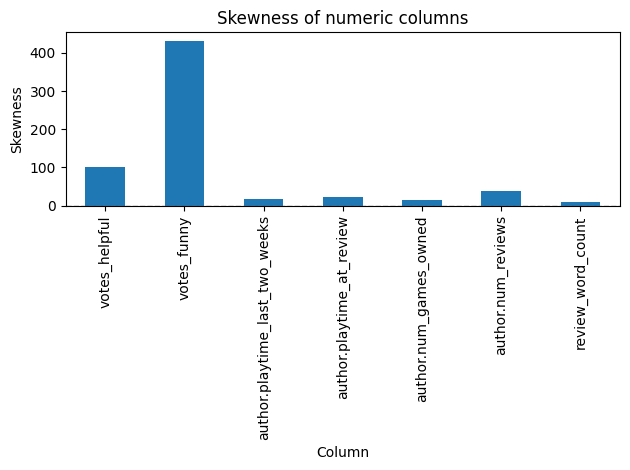

In [28]:
# Compute skewness for each selected numeric column
skewness_results = {}
for col in COLS_TO_COMPARE:
    if col in df.columns:
        # dropna to handle missing values cleanly
        skew_val = df[col].dropna().skew()
        skewness_results[col] = skew_val
    else:
        skewness_results[col] = None

# Display the skewness values
print("Skewness of numeric columns:")
for col, skew_val in skewness_results.items():
    print(f"{col}: {skew_val}")

# Filter out columns that are missing
skew_series = pd.Series({k: v for k, v in skewness_results.items() if v is not None})

# Plot skewness as a bar plot
skew_series.plot.bar(
    title="Skewness of numeric columns", xlabel="Column", ylabel="Skewness"
)
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()

# Skewness interpretation tip:
# - Skewness > 1 or < -1 indicates highly skewed distributions (long tail).
# - Skewness near 0 means distribution is fairly symmetrical.
# Comparing raw vs transformed skewness helps decide need for normalization.


Kurtosis of numeric columns:
votes_helpful: 17191.00421827859
votes_funny: 186638.9999744566
author.playtime_last_two_weeks: 385.6872965158337
author.playtime_at_review: 1120.9178675413052
author.num_games_owned: 415.0581404966574
author.num_reviews: 3328.385789291402
review_word_count: 108.18196314088286


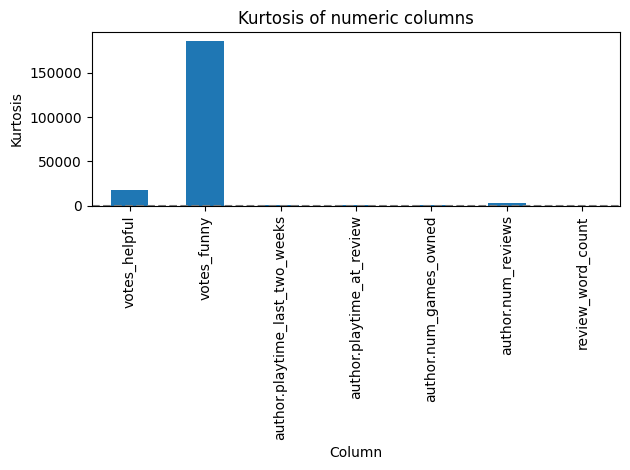

In [29]:
# Kurtosis can be a useful metric when exploring normalization/transforms, especially alongside skewness.
# It measures the "tailedness" of the distribution—high kurtosis means more outliers/extreme values.
# This is relevant for count/playtime columns where long tails or outliers can influence model performance and scaling decisions.

# Let's compute kurtosis for the same columns and visualize it as a bar plot:

kurtosis_results = {}
for col in COLS_TO_COMPARE:
    if col in df.columns:
        # Use dropna to avoid NaN distortion
        kurt_val = df[col].dropna().kurt()
        kurtosis_results[col] = kurt_val
    else:
        kurtosis_results[col] = "Not in DataFrame"

print("\nKurtosis of numeric columns:")
for col, kurt_val in kurtosis_results.items():
    print(f"{col}: {kurt_val}")

# Plot kurtosis for numeric columns
kurt_series = pd.Series(
    {k: v for k, v in kurtosis_results.items() if isinstance(v, (int, float))}
)
kurt_series.plot.bar(
    title="Kurtosis of numeric columns", xlabel="Column", ylabel="Kurtosis"
)
plt.axhline(0, color="gray", linestyle="--")
plt.tight_layout()
plt.show()

# Interpretation tip:
# - High (>3): "heavy tails" (many outliers/extreme values).
# - Near 0: similar to normal distribution.
# Comparing raw vs transformed kurtosis helps spot if normalization reduces outlier impact.

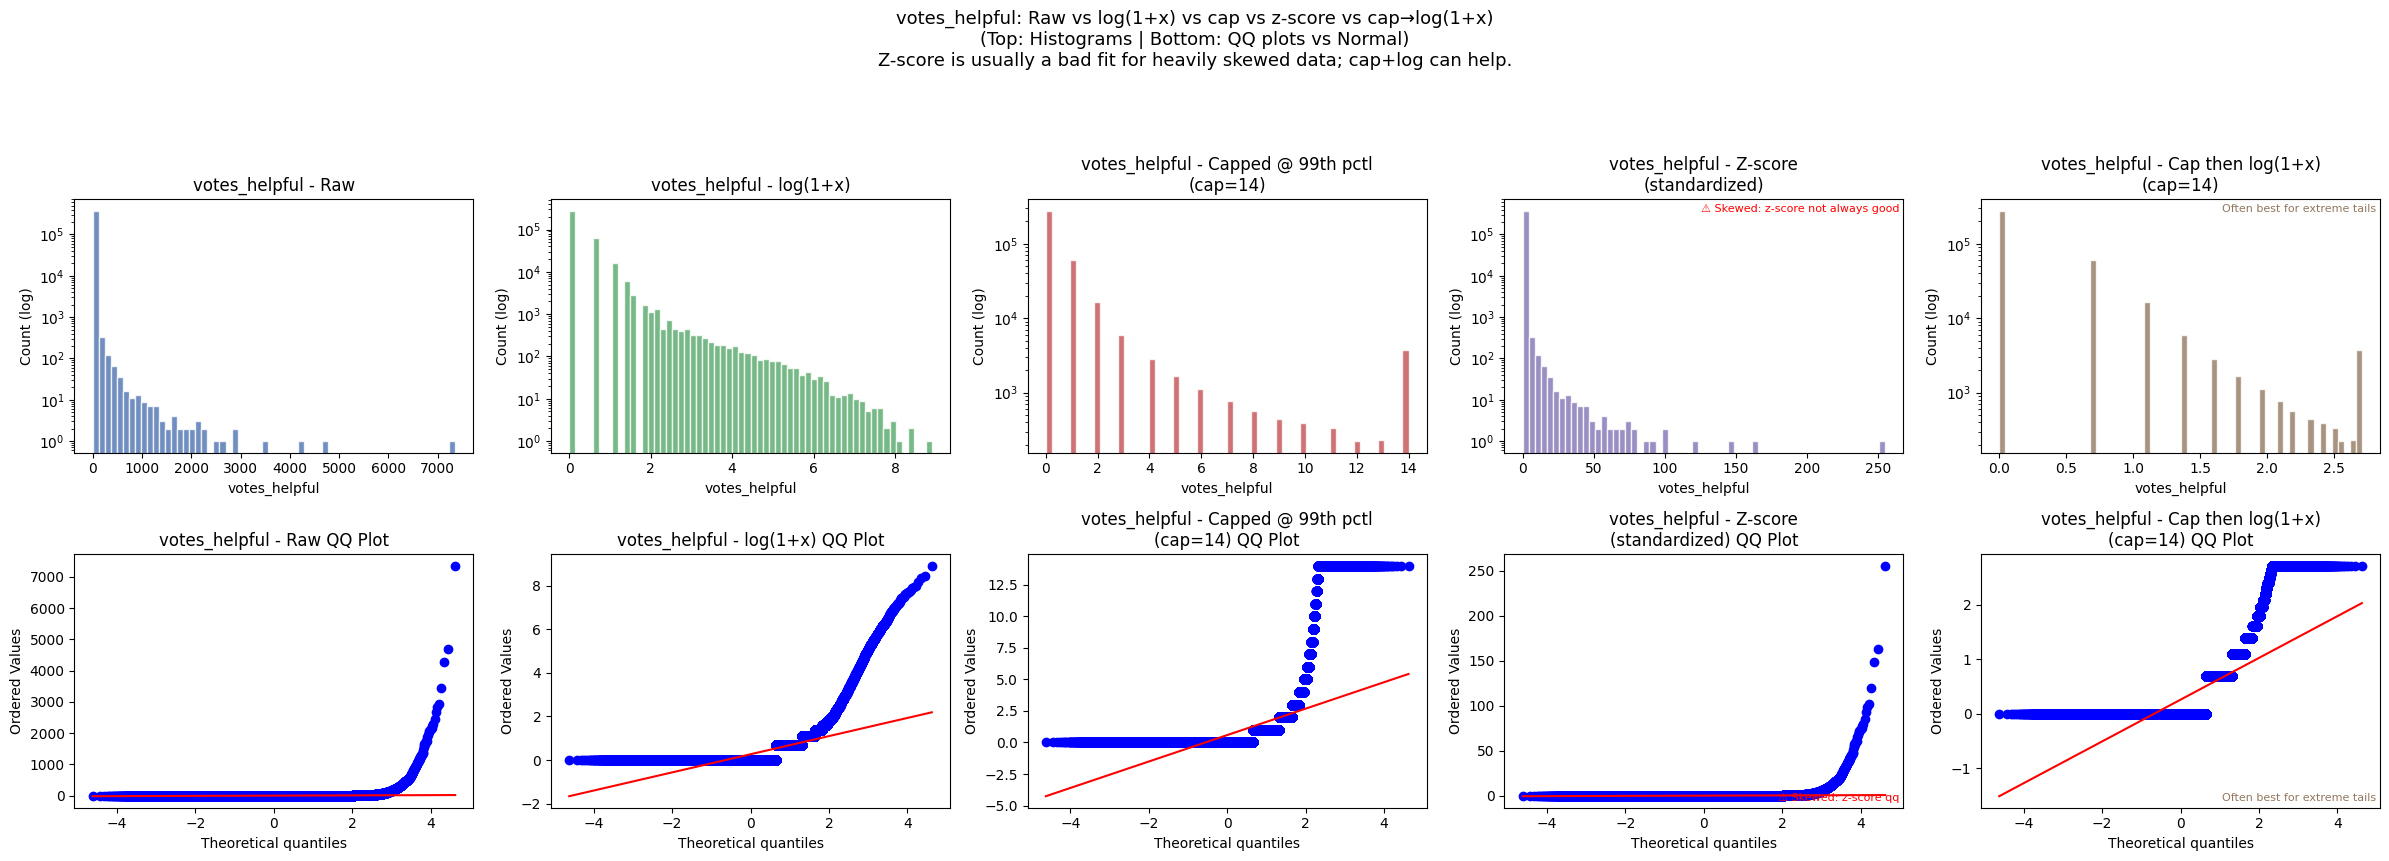

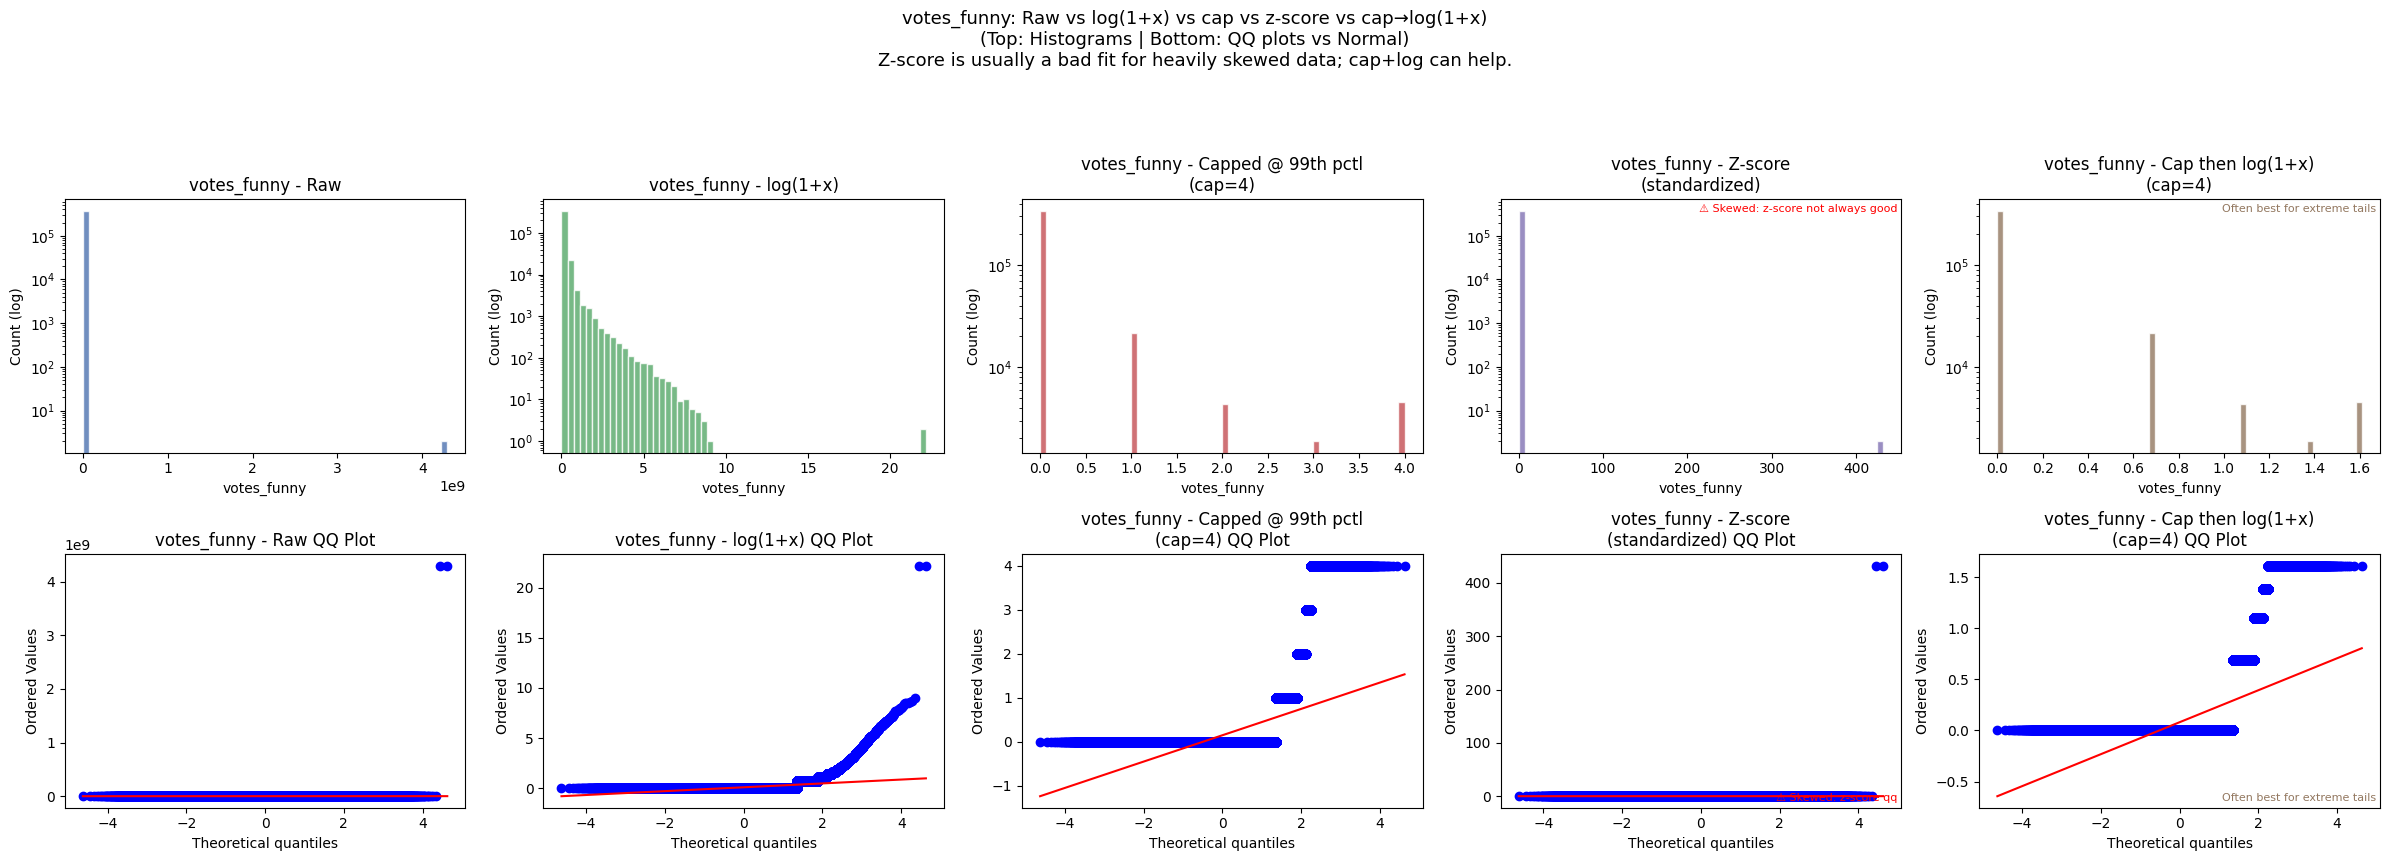

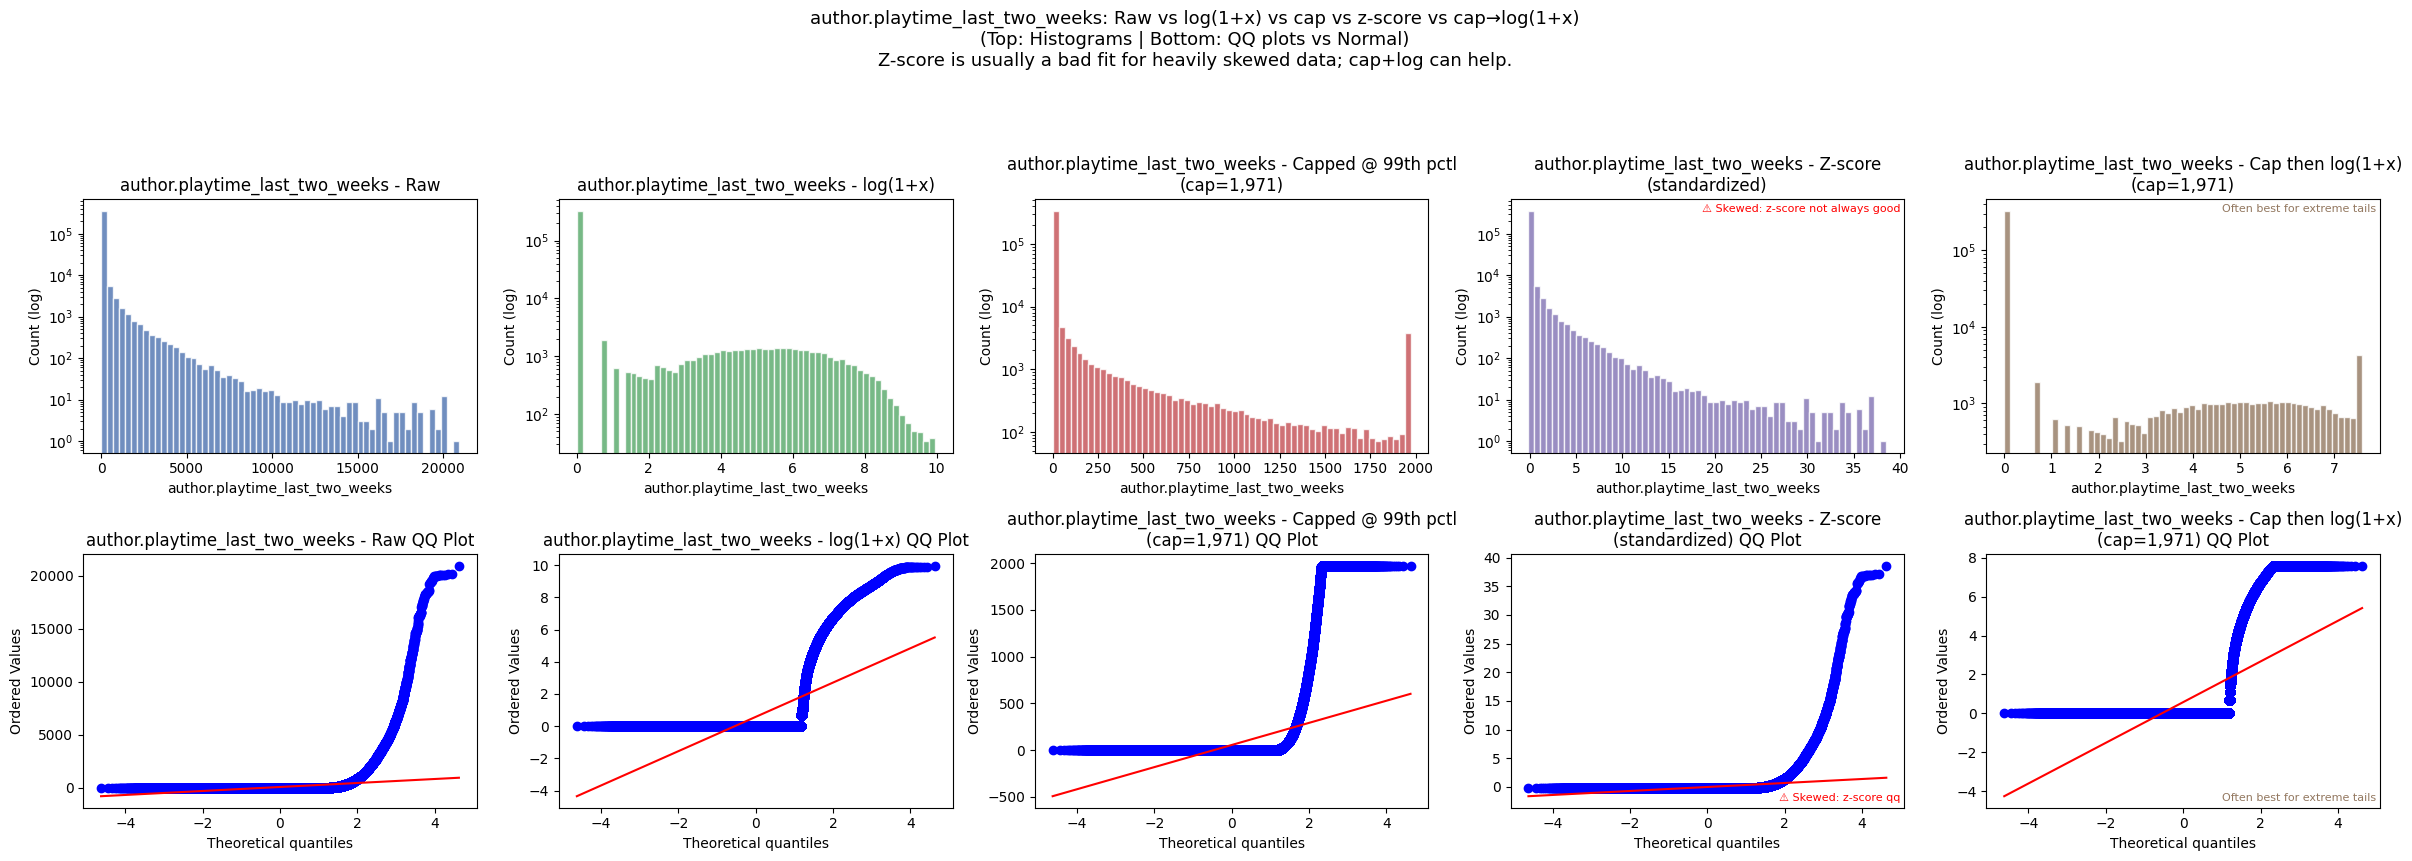

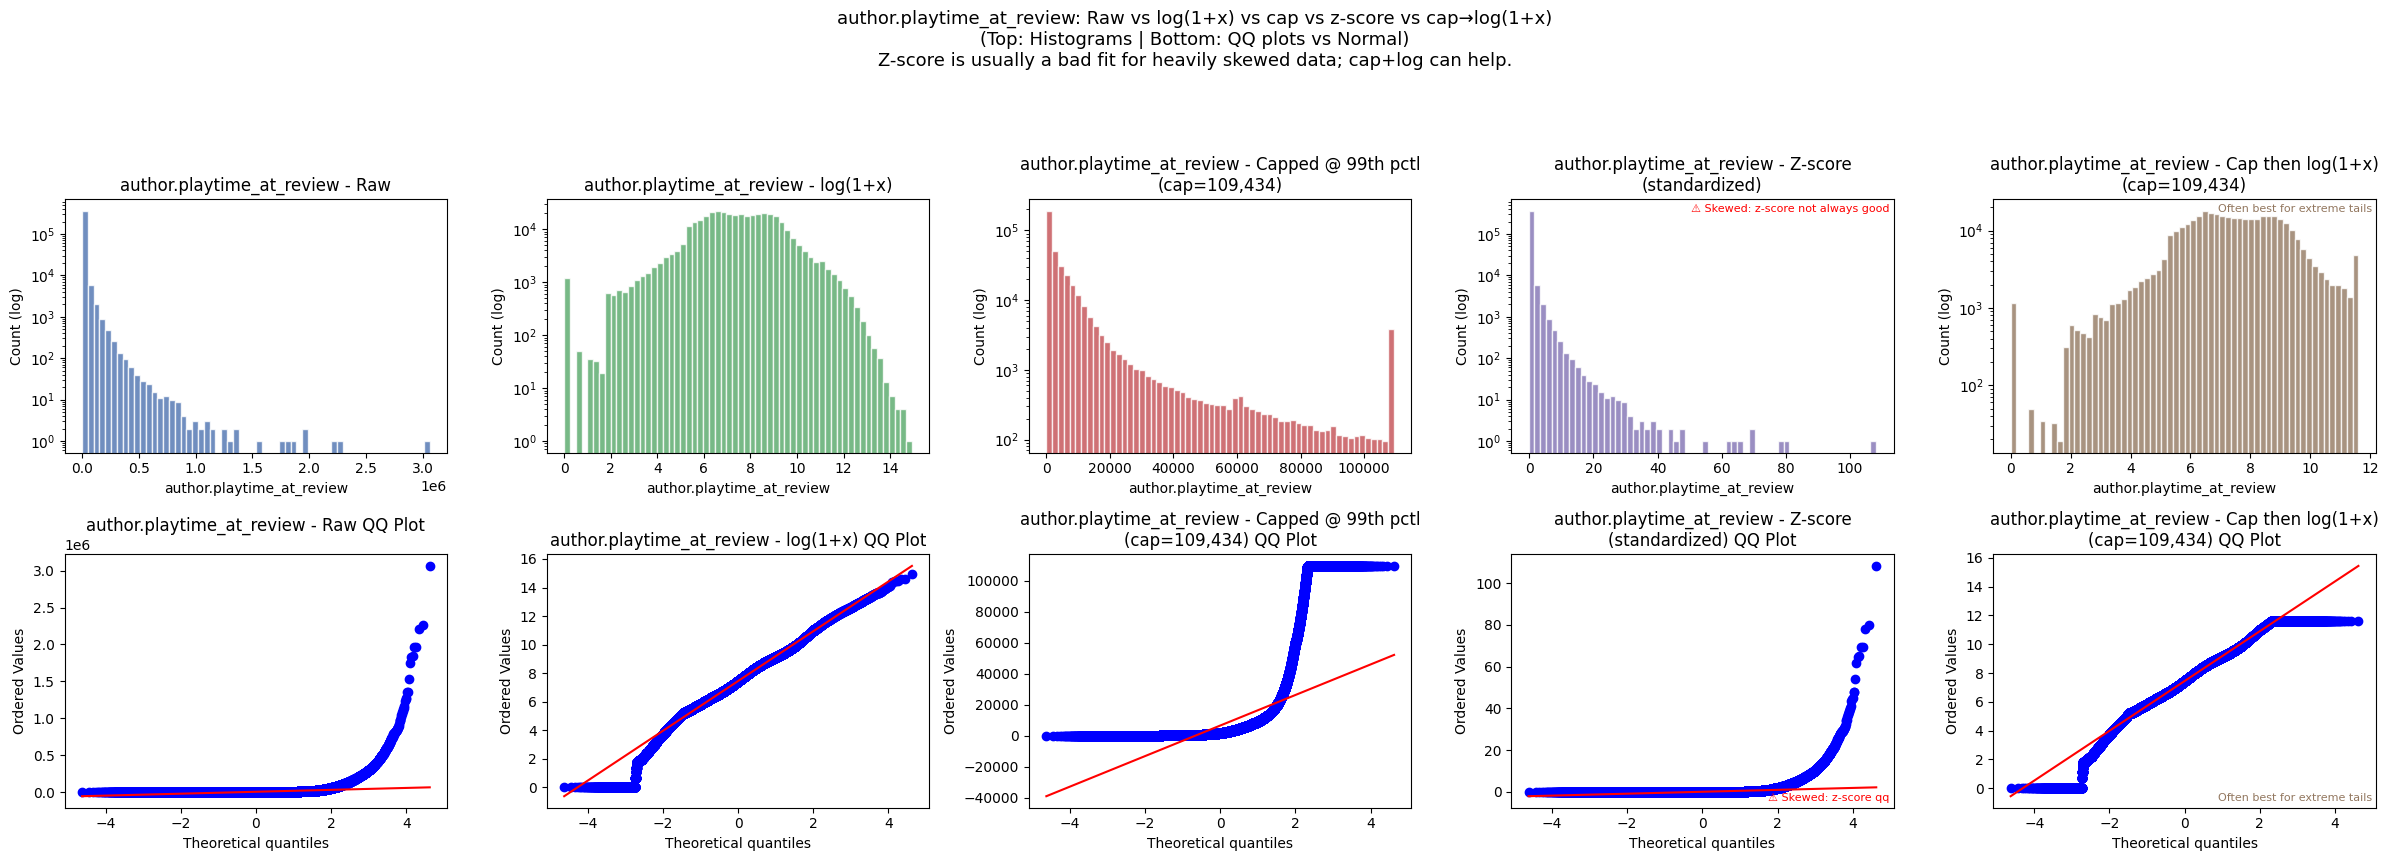

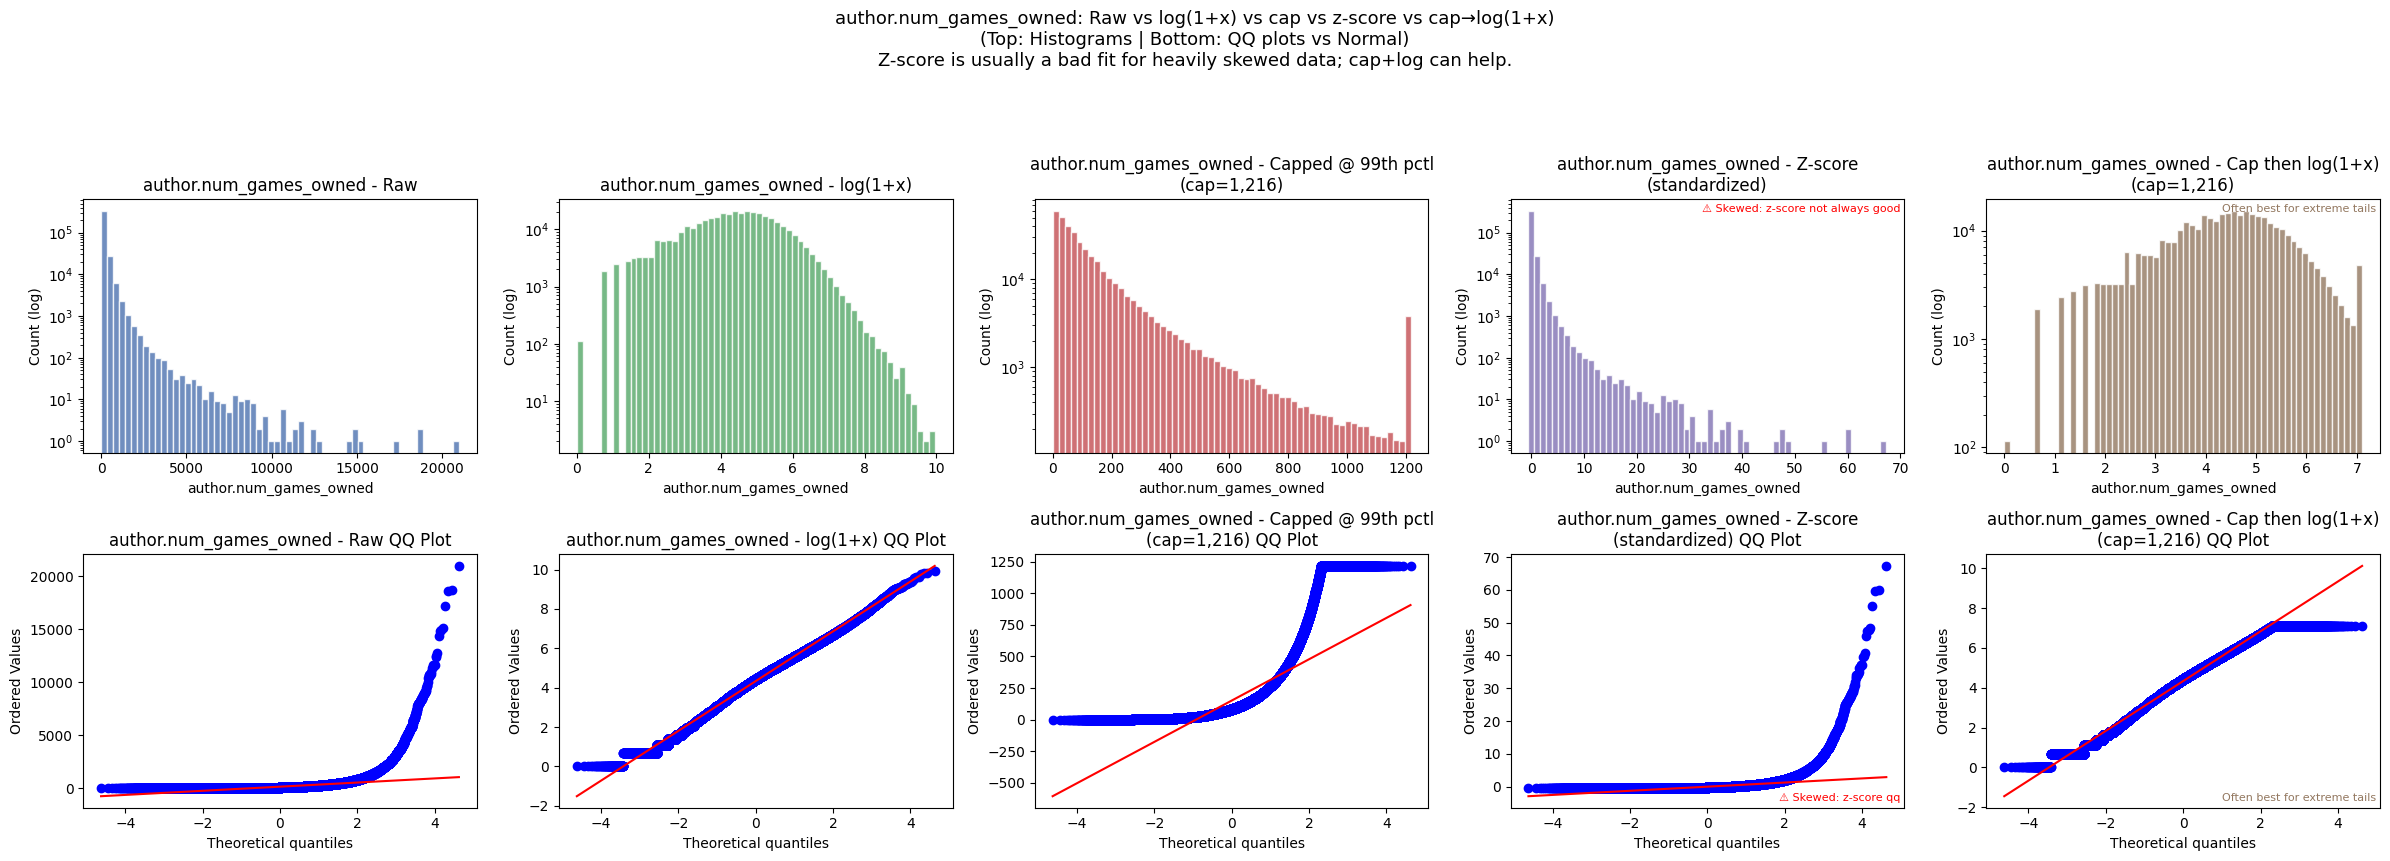

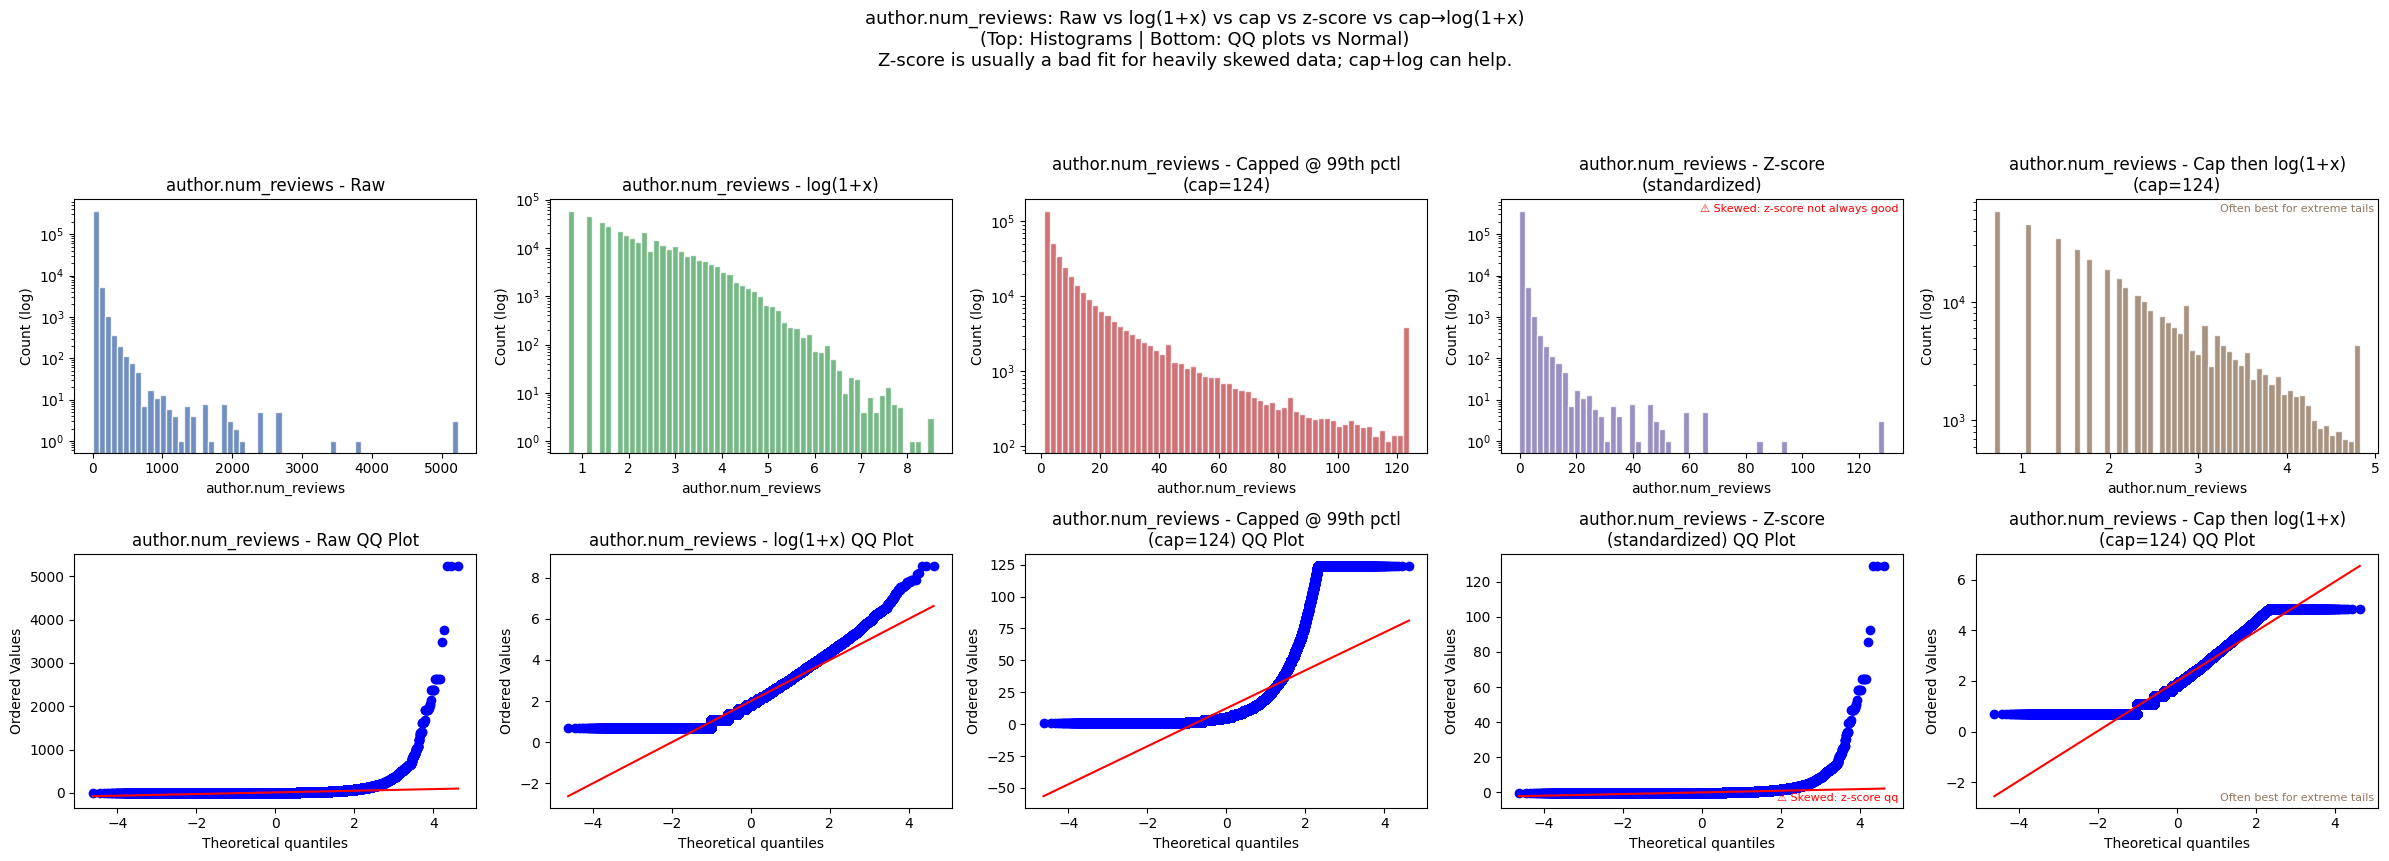

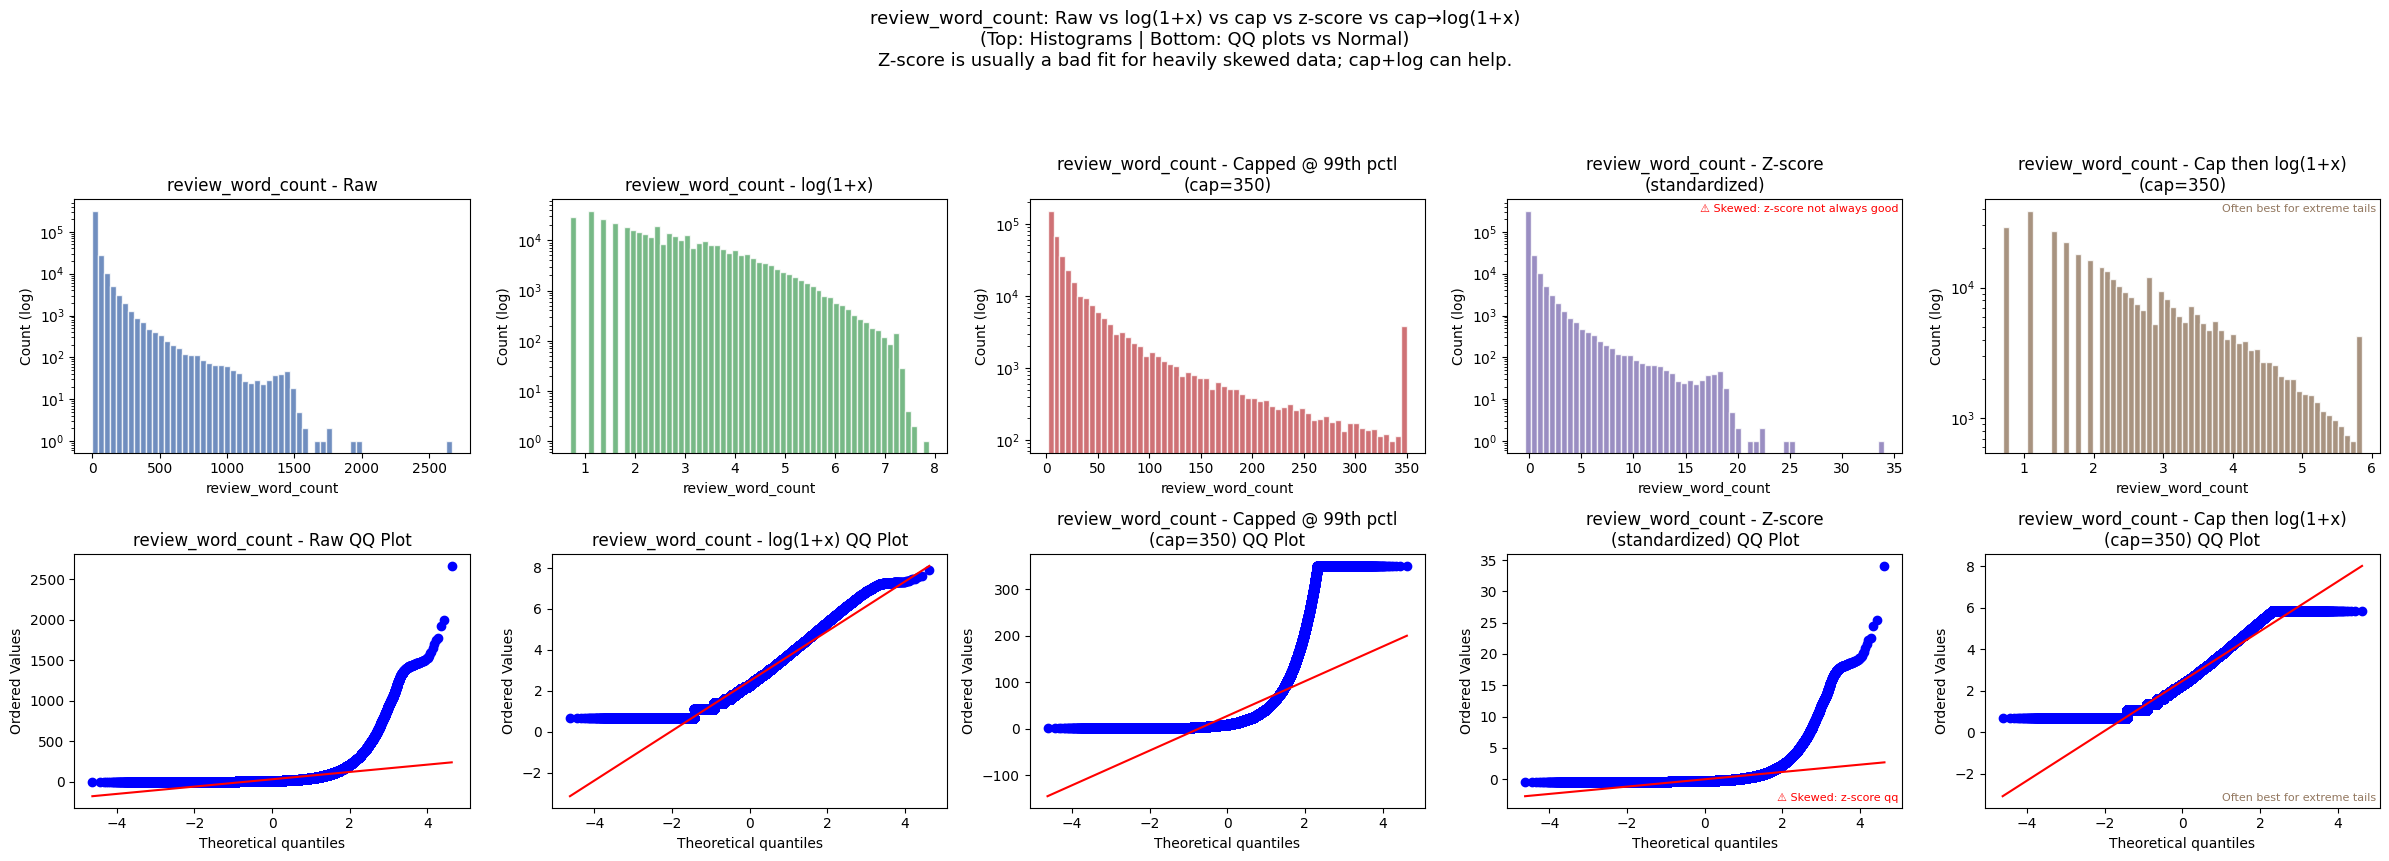

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# For each column: show (row 1) histograms of transform; (row 2) QQ plots vs Normal
for col in COLS_TO_COMPARE:
    if col not in df.columns:
        print(f"Column '{col}' not found, skipping.")
        continue

    data = df[col].copy()

    # Compute cap at 99th percentile
    cap_val = np.nanpercentile(data, 99)

    # Prepare transformed versions
    data_raw = data
    data_log1p = np.log1p(data)
    data_cap = data.clip(upper=cap_val)
    data_zscore = (data - data.mean()) / data.std()
    data_cap_log1p = np.log1p(data_cap)  # log(1+x) after capping
    # 'cap then log' is often more interpretable for count data with extreme outliers

    transforms = [
        ("Raw", data_raw, "#4C72B0"),
        ("log(1+x)", data_log1p, "#55A868"),
        (f"Capped @ 99th pctl\n(cap={cap_val:,.0f})", data_cap, "#C44E52"),
        ("Z-score\n(standardized)", data_zscore, "#8172B3"),
        (f"Cap then log(1+x)\n(cap={cap_val:,.0f})", data_cap_log1p, "#937860"),
    ]

    fig, axs = plt.subplots(2, 5, figsize=(24, 8))

    # Row 1: Histograms
    for i, (label, arr, color) in enumerate(transforms):
        axs[0, i].hist(arr.dropna(), bins=60, color=color, alpha=0.8, edgecolor="white")
        axs[0, i].set_title(f"{col} - {label}")
        axs[0, i].set_yscale("log")
        axs[0, i].set_xlabel(col)
        axs[0, i].set_ylabel("Count (log)")
        if i == 3:  # Z-score warning
            axs[0, i].text(
                0.99,
                0.98,
                "⚠️ Skewed: z-score not always good",
                ha="right",
                va="top",
                color="red",
                fontsize=8,
                transform=axs[0, i].transAxes,
            )
        if i == 4:  # cap-log info
            axs[0, i].text(
                0.99,
                0.98,
                "Often best for extreme tails",
                ha="right",
                va="top",
                color="#937860",
                fontsize=8,
                transform=axs[0, i].transAxes,
            )

    # Row 2: QQ plots
    for i, (label, arr, color) in enumerate(transforms):
        clean_arr = arr.dropna()
        stats.probplot(clean_arr, dist="norm", plot=axs[1, i])
        axs[1, i].set_title(f"{col} - {label} QQ Plot")
        if i == 3:
            axs[1, i].text(
                0.99,
                0.02,
                "⚠️ Skewed: z-score qq",
                ha="right",
                va="bottom",
                color="red",
                fontsize=8,
                transform=axs[1, i].transAxes,
            )
        if i == 4:
            axs[1, i].text(
                0.99,
                0.02,
                "Often best for extreme tails",
                ha="right",
                va="bottom",
                color="#937860",
                fontsize=8,
                transform=axs[1, i].transAxes,
            )

    fig.suptitle(
        f"{col}: Raw vs log(1+x) vs cap vs z-score vs cap→log(1+x)\n"
        "(Top: Histograms | Bottom: QQ plots vs Normal)\n"
        "Z-score is usually a bad fit for heavily skewed data; cap+log can help.",
        fontsize=13,
        y=1.07,
    )
    plt.tight_layout()
    plt.show()

# Final normalization choices (applied)

Apply the chosen transforms to the sample and store in a copy for inspection:

- **Cap then log:** `votes_helpful`, `author.playtime_last_two_weeks` (cap at 99th percentile, then log1p).
- **Log only:** `votes_funny`, `author.playtime_at_review`, `author.num_games_owned`, `author.num_reviews`.

Cap values are computed from this sample; in production, fit on training data and reuse.

# Comparing Various Implementations

In [ ]:
# Column lists (match your select_features output)
CAP_THEN_LOG_COLS = ["votes_helpful", "author.playtime_last_two_weeks"]
LOG_ONLY_COLS = [
    "votes_funny",
    "author.playtime_at_review",
    "author.num_games_owned",
    "author.num_reviews",
    "review_word_count",
]
NORM_COLS = CAP_THEN_LOG_COLS + LOG_ONLY_COLS

## Original implementation

In [32]:
from pathlib import Path
from steam_review_ml.data.loaders import load_raw_reviews
from steam_review_ml.data.preprocess import filter_reviews, select_features

RAW_PATH = Path("../../data/raw/steam_reviews_full.csv")
df_raw = load_raw_reviews(RAW_PATH, nrows=1_000_000)
df_clean = filter_reviews(df_raw)
df = select_features(df_clean)
df = add_review_word_count(df)
print(df.shape)

(373283, 24)


In [33]:
df.columns

Index(['review_id', 'app_id', 'app_name', 'author.steamid', 'review',
       'recommended', 'votes_helpful', 'author.num_games_owned',
       'author.num_reviews', 'author.playtime_last_two_weeks',
       'author.playtime_at_review', 'votes_funny', 'comment_count',
       'steam_purchase', 'received_for_free', 'written_during_early_access',
       'timestamp_created', 'timestamp_updated', 'author.last_played',
       'is_helpful', 'review_length_chars',
       'author_playtime_last_two_weeks_missing',
       'author_playtime_at_review_missing', 'review_word_count'],
      dtype='str')

In [ ]:
# Apply the correct transformation for each column:
transformed = {}
for col in NORM_COLS:
    data_raw = df[col]
    if col in CAP_THEN_LOG_COLS:
        # Compute cap value for this column (here, example 99th percentile)
        cap_val = np.percentile(data_raw, 99)
        data_cap = data_raw.clip(upper=cap_val)
        transformed[col] = np.log1p(data_cap)
    else:  # col in LOG_ONLY_COLS
        transformed[col] = np.log1p(data_raw)
# `transformed` now holds the normalized columns keyed by their name

# Convert the transformed dict into a pandas DataFrame, matching df index
df_cap_log = pd.DataFrame(transformed, index=df.index)
display(df_cap_log.describe())

,votes_helpful,author.playtime_last_two_weeks,votes_funny,author.playtime_at_review,author.num_games_owned,author.num_reviews
count,373283.000000,373283.000000,373283.000000,373283.000000,373283.000000,373283.000000
mean,0.256175,0.575543,0.092224,7.448884,4.337872,2.000362
std,0.509201,1.700466,0.380626,1.752870,1.267242,1.030242
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.693147
25%,0.000000,0.000000,0.000000,6.315358,3.526361,1.098612
50%,0.000000,0.000000,0.000000,7.443664,4.418841,1.791759
75%,0.693147,0.000000,0.000000,8.681181,5.198497,2.639057
max,2.708050,7.586804,22.180710,14.934835,9.950848,8.563504


In [ ]:
df_cap_log.head()

,votes_helpful,author.playtime_last_two_weeks,votes_funny,author.playtime_at_review,author.num_games_owned,author.num_reviews
3,0.0,7.586804,0.0,8.617039,1.791759,1.386294
5,0.0,6.714171,0.0,6.714171,2.484907,0.693147
6,0.0,7.586804,0.0,8.341172,3.332205,1.098612
18,0.0,5.181784,0.0,10.057495,3.526361,0.693147
20,0.0,7.586804,0.0,9.054622,4.882802,1.098612


## sklearn implementation

In [36]:
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer


# Minimal transformer: cap at fitted percentile, then log1p
class CapThenLogTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, percentile=99.0):
        self.percentile = percentile

    def fit(self, X, y=None):
        X = np.asarray(X)
        self.cap_ = np.nanpercentile(X, self.percentile, axis=0)
        if self.cap_.ndim == 0:
            self.cap_ = np.atleast_1d(self.cap_)
        self.n_features_in_ = X.shape[1]
        return self

    def transform(self, X):
        X = np.asarray(X)
        return np.log1p(np.clip(X, None, self.cap_))


ct = ColumnTransformer(
    [
        ("cap_then_log", CapThenLogTransformer(percentile=99.0), CAP_THEN_LOG_COLS),
        ("log_only", FunctionTransformer(np.log1p), LOG_ONLY_COLS),
    ],
    remainder="passthrough",
    verbose_feature_names_out=False,
)

In [37]:
# Fit on this sample; in production you'd fit on train only
ct.fit(df[NORM_COLS])

# Transform and put back into a DataFrame
arr = ct.transform(df[NORM_COLS])
out_cols = CAP_THEN_LOG_COLS + LOG_ONLY_COLS
df_sklearn = pd.DataFrame(arr, columns=out_cols, index=df.index)

# Fitted caps (from cap_then_log step)
cap_trans = ct.named_transformers_["cap_then_log"]
print(
    "Fitted cap values (99th %ile):",
    dict(zip(CAP_THEN_LOG_COLS, cap_trans.cap_.tolist())),
)
display(df_sklearn.describe())

Fitted cap values (99th %ile): {'votes_helpful': 14.0, 'author.playtime_last_two_weeks': 1971.0}


,votes_helpful,author.playtime_last_two_weeks,votes_funny,author.playtime_at_review,author.num_games_owned,author.num_reviews
count,373283.000000,373283.000000,373283.000000,373283.000000,373283.000000,373283.000000
mean,0.256175,0.575543,0.092224,7.448884,4.337872,2.000362
std,0.509201,1.700466,0.380626,1.752870,1.267242,1.030242
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.693147
25%,0.000000,0.000000,0.000000,6.315358,3.526361,1.098612
50%,0.000000,0.000000,0.000000,7.443664,4.418841,1.791759
75%,0.693147,0.000000,0.000000,8.681181,5.198497,2.639057
max,2.708050,7.586804,22.180710,14.934835,9.950848,8.563504


In [38]:
df_sklearn.head(5)

,votes_helpful,author.playtime_last_two_weeks,votes_funny,author.playtime_at_review,author.num_games_owned,author.num_reviews
3,0.0,7.586804,0.0,8.617039,1.791759,1.386294
5,0.0,6.714171,0.0,6.714171,2.484907,0.693147
6,0.0,7.586804,0.0,8.341172,3.332205,1.098612
18,0.0,5.181784,0.0,10.057495,3.526361,0.693147
20,0.0,7.586804,0.0,9.054622,4.882802,1.098612


## Tensorflow Implementation

In [39]:
import tensorflow as tf

CAP_P = 0.99

caps = {col: df[col].quantile(CAP_P) for col in CAP_THEN_LOG_COLS}
caps

{'votes_helpful': np.float64(14.0),
 'author.playtime_last_two_weeks': np.float64(1971.0)}

In [40]:
class SteamNormalizer(tf.keras.layers.Layer):
    """
    Apply cap-then-log or log-only to numeric features.

    inputs: dict(name -> tensor), each tensor shape (batch,) or (batch, 1)
    """

    def __init__(self, caps, cap_then_log_cols, log_only_cols, **kwargs):
        super().__init__(**kwargs)
        self.caps = caps
        self.cap_then_log_cols = cap_then_log_cols
        self.log_only_cols = log_only_cols

    def call(self, inputs):
        # copy to avoid mutating caller's dict
        x = {k: tf.convert_to_tensor(v) for k, v in inputs.items()}

        # cap then log1p
        for col in self.cap_then_log_cols:
            c = tf.cast(self.caps[col], x[col].dtype)
            x[col] = tf.math.log1p(tf.minimum(x[col], c))

        # log1p only
        for col in self.log_only_cols:
            x[col] = tf.math.log1p(x[col])

        return x

In [41]:
# Keras Inputs (one per column)
inputs = {
    col: tf.keras.Input(shape=(1,), name=col, dtype=tf.float32)
    for col in (CAP_THEN_LOG_COLS + LOG_ONLY_COLS)
}

norm_layer = SteamNormalizer(
    caps=caps,
    cap_then_log_cols=CAP_THEN_LOG_COLS,
    log_only_cols=LOG_ONLY_COLS,
)

norm_features = norm_layer(inputs)  # dict of normalized tensors

# Example: concatenate for a dense model
conc = tf.keras.layers.Concatenate()(list(norm_features.values()))
x = tf.keras.layers.Dense(64, activation="relu")(conc)
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs)

In [42]:
batch = {
    col: tf.constant(df[col].values.reshape(-1, 1), dtype=tf.float32)
    for col in (CAP_THEN_LOG_COLS + LOG_ONLY_COLS)
}

batch_norm = norm_layer(batch)
batch_norm["votes_helpful"][:5]

<tf.Tensor: shape=(5, 1), dtype=float32, numpy=
array([[0.],
       [0.],
       [0.],
       [0.],
       [0.]], dtype=float32)>

# Visualization

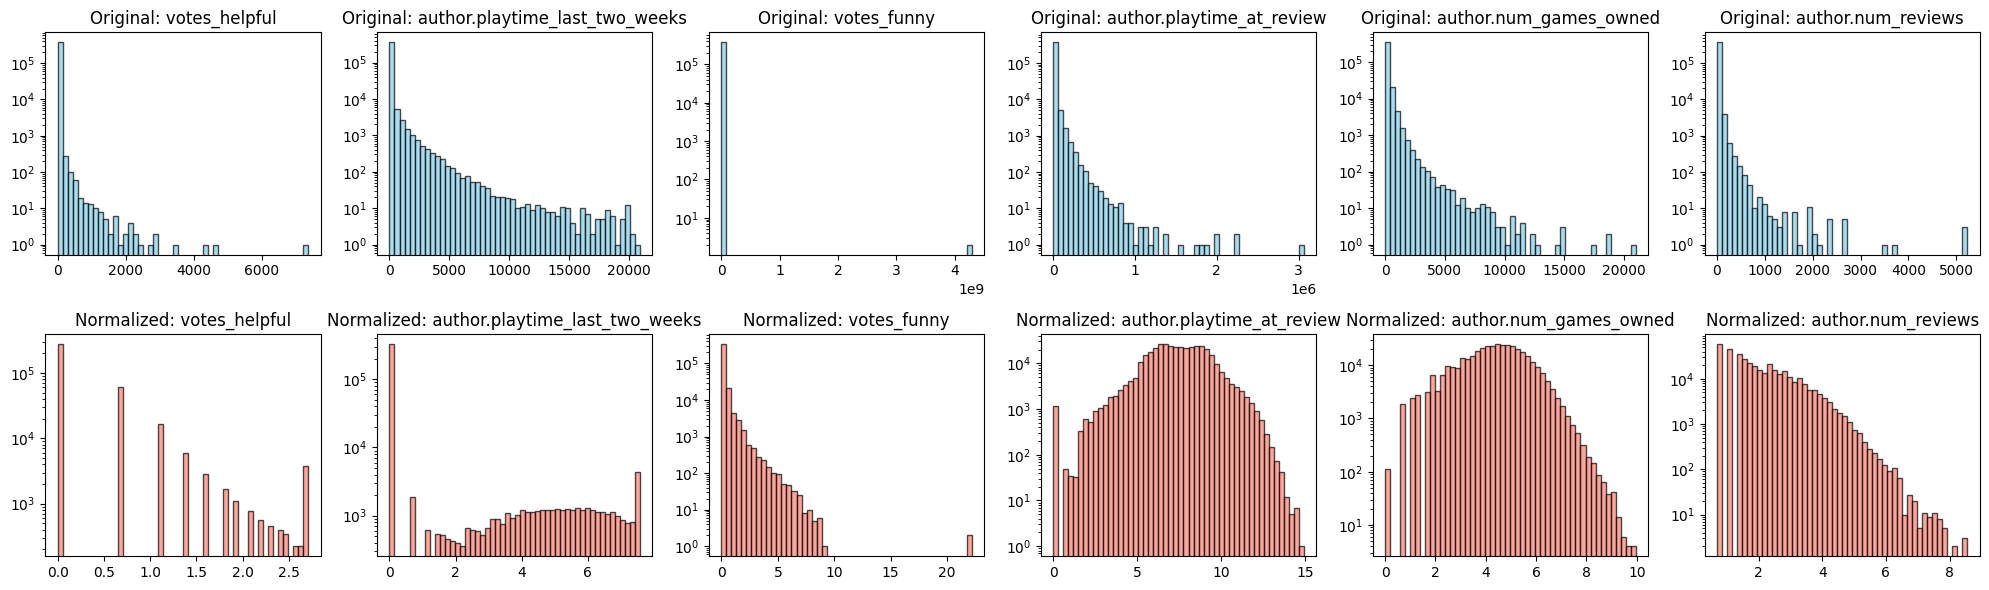

In [43]:
import matplotlib.pyplot as plt

# Visualize distributions (histogram) for each normalized feature
fig, axes = plt.subplots(2, len(batch_norm), figsize=(20, 6))

for i, col in enumerate(batch_norm):
    # Original distribution
    axes[0, i].hist(
        df[col], bins=50, log=True, alpha=0.7, color="skyblue", edgecolor="k"
    )
    axes[0, i].set_title(f"Original: {col}")
    axes[0, i].set_yscale("log")

    # Normalized distribution
    axes[1, i].hist(
        batch_norm[col].numpy().flatten(),
        bins=50,
        log=True,
        alpha=0.7,
        color="salmon",
        edgecolor="k",
    )
    axes[1, i].set_title(f"Normalized: {col}")
    axes[1, i].set_yscale("log")

plt.tight_layout()
plt.show()

### Compare normalization variants (original, cap+log, sklearn, TensorFlow)

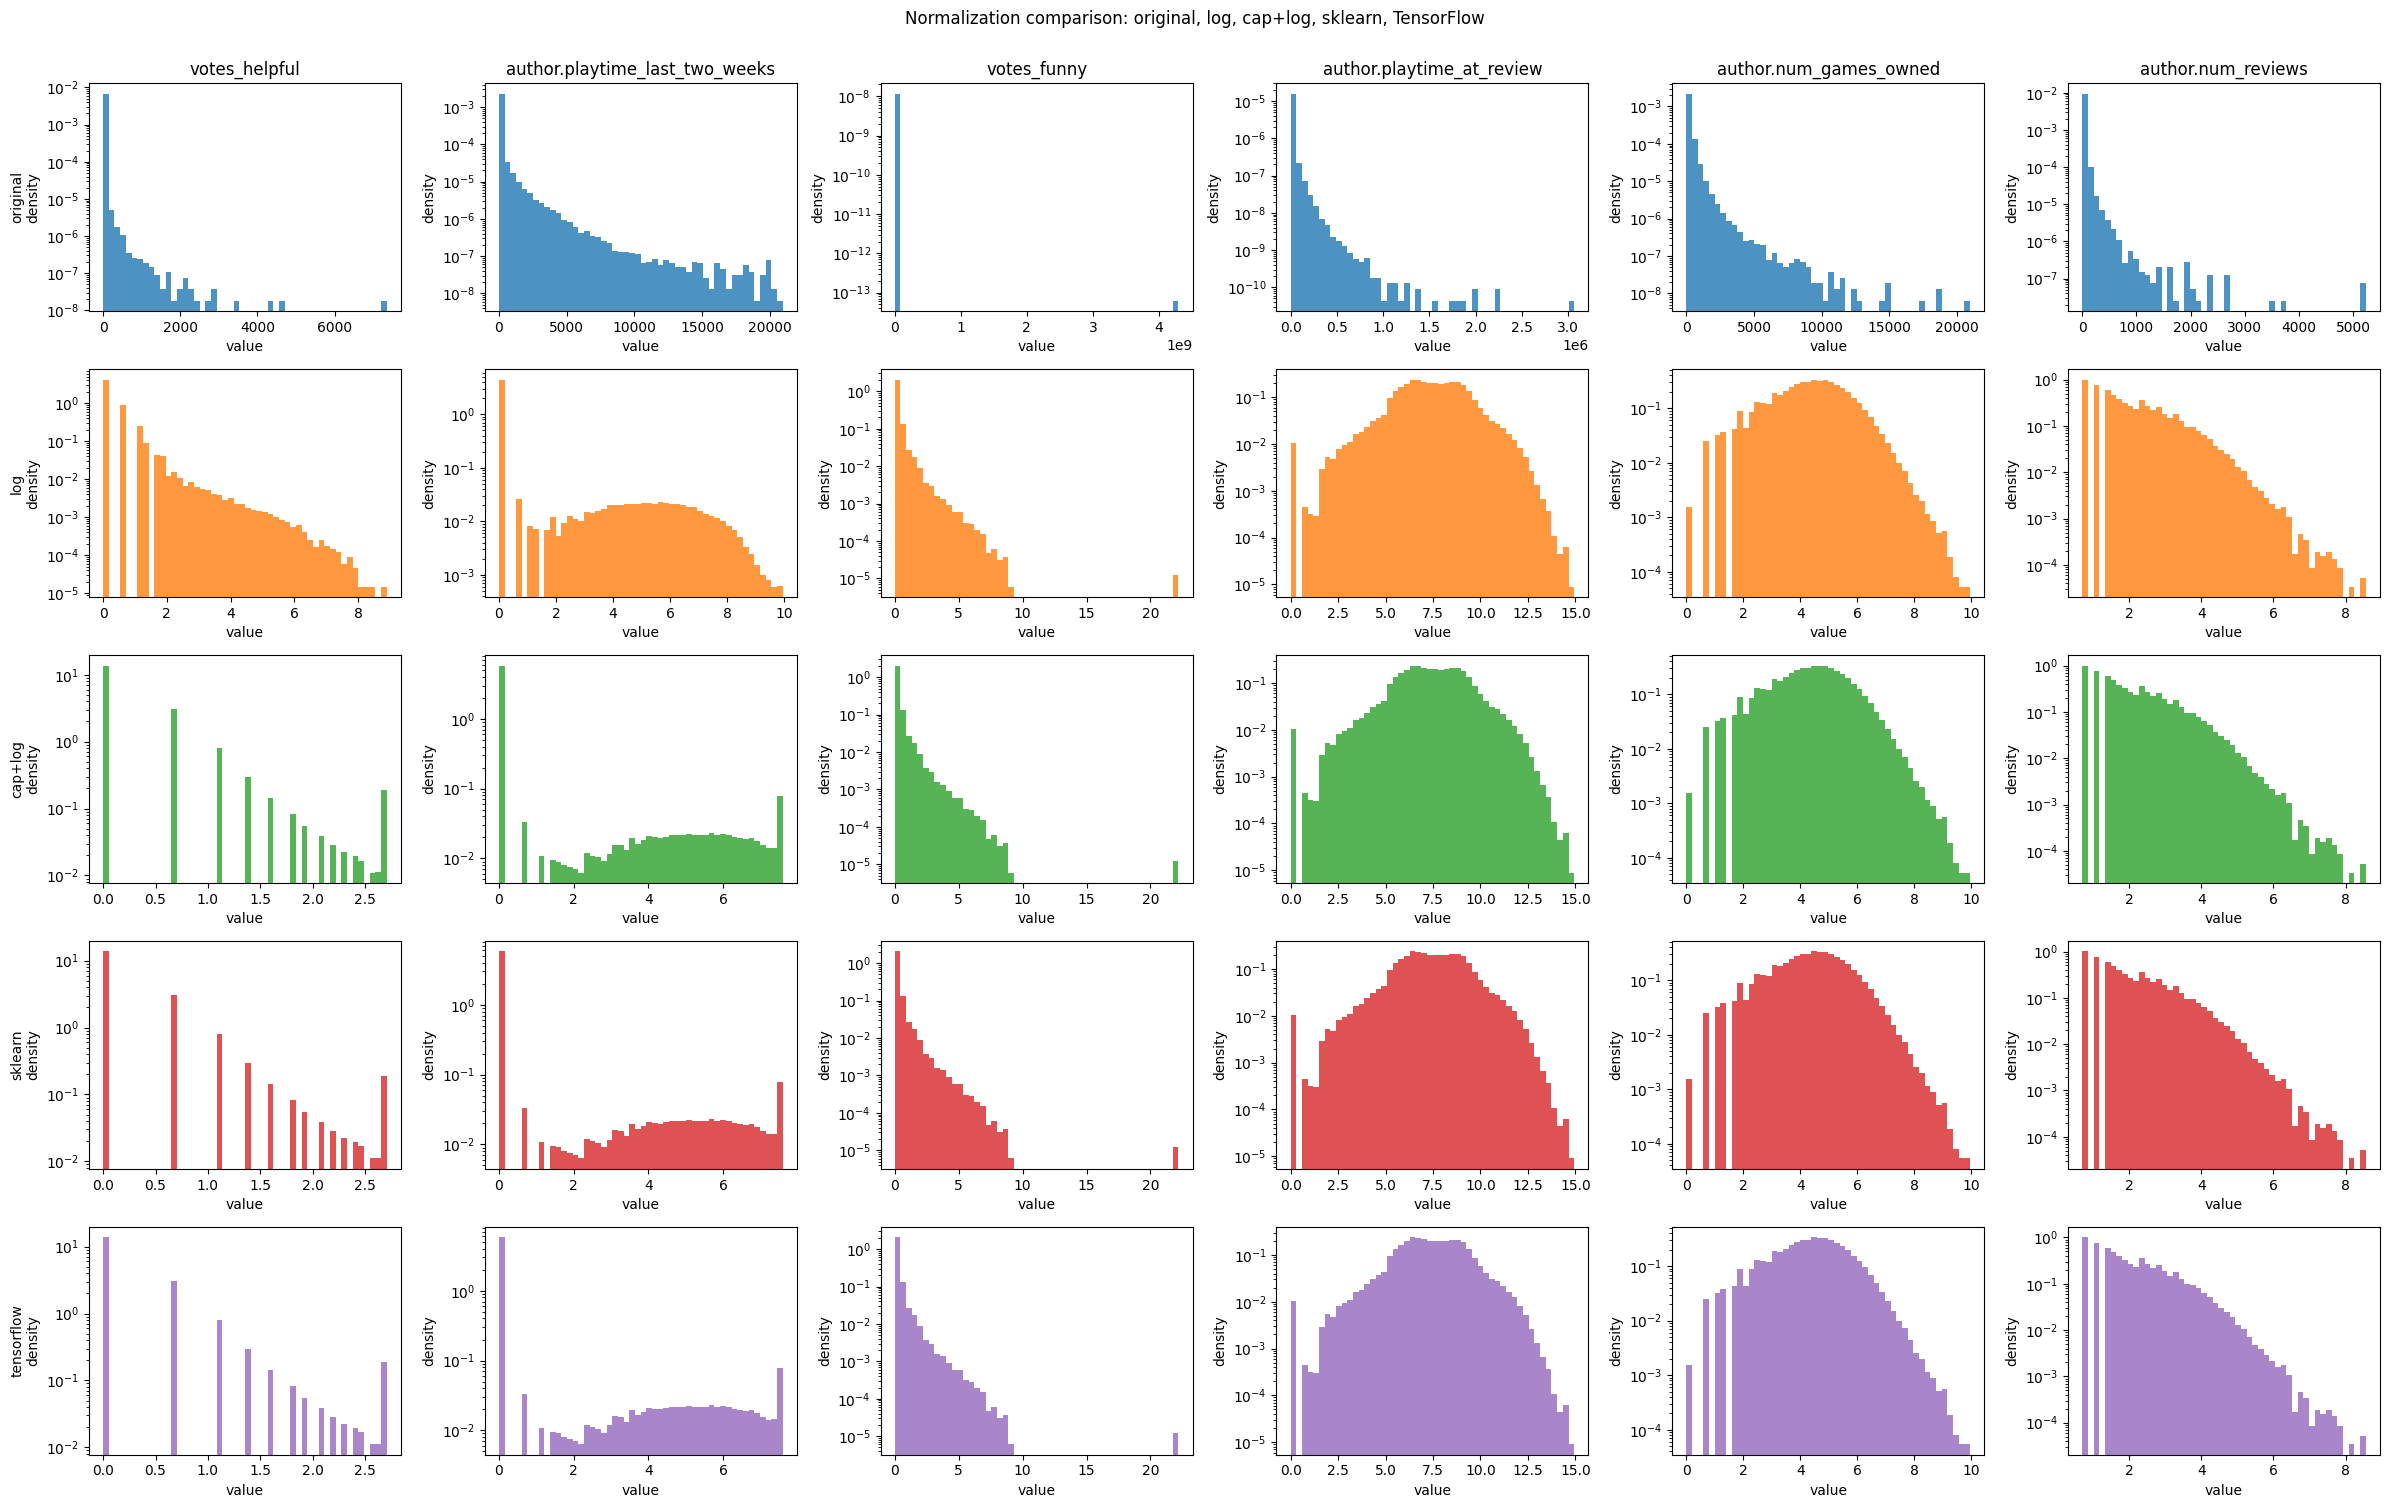

In [ ]:
# Use already-computed variants; add "log only" (log1p on all, no cap) for full comparison
df_raw = df[NORM_COLS].copy()
df_tf = pd.DataFrame(
    {col: batch_norm[col].numpy().flatten() for col in NORM_COLS}, index=df.index
)

# One row per variant, one column per feature (so scales don't hide anything)
variants = [
    ("original", df_raw, "#1f77b4"),
    ("cap+log", df_cap_log, "#2ca02c"),
    ("sklearn", df_sklearn, "#d62728"),
    ("tensorflow", df_tf, "#9467bd"),
]
ncols = len(NORM_COLS)
nrows = len(variants)
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
if nrows == 1:
    axes = axes.reshape(1, -1)
if ncols == 1:
    axes = axes.reshape(-1, 1)
for j, col in enumerate(NORM_COLS):
    for i, (label, data, color) in enumerate(variants):
        ax = axes[i, j]
        ax.hist(
            data[col].dropna(),
            bins=50,
            alpha=0.8,
            color=color,
            density=True,
            histtype="stepfilled",
        )
        ax.set_ylabel("density")
        ax.set_yscale("log")
        if i == 0:
            ax.set_title(col)
        if j == 0:
            ax.set_ylabel(f"{label}\ndensity")
        else:
            ax.set_ylabel("density")
for ax in axes.flat:
    ax.set_xlabel("value")
plt.suptitle(
    "Normalization comparison: original, log, cap+log, sklearn, TensorFlow", y=1.002
)
plt.tight_layout()
plt.show()